In [1]:
import numpy as np
import json
import pandas as pd
import itertools

import astropy.units as u

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

from scipy.interpolate import interp1d
from scipy.stats import binom
from scipy.ndimage import gaussian_filter

from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.redshift_utils import *
from darksirenpop.utilities.utils import *

make_nice_plots()


In [2]:
# Define paths
DATA_DIR = "/home/lucas/Documents/PhD/generated_data"

JSON_DIR = f"{DATA_DIR}/jsons"
FAGN_POSTERIOR_DIR = f"{DATA_DIR}/fagn_posteriors"
AGN_DIST_DIR = f"{DATA_DIR}/em"
MOCK_GW_DIR = f"{DATA_DIR}/mock_gws"
PDET_DIR = f"{DATA_DIR}/compare_PdetEM_methods"
CATALOG_PATH = f"{DATA_DIR}/em/quaia_zleq3_withlumcorr.csv"

quaia = pd.read_csv(CATALOG_PATH)
median_err_quaia = np.median( quaia["redshift_quaia_err"] )


In [3]:
def load_log_llh(filename, subdir, fagn_true=None, verbose=False):
	data = np.load(f'{FAGN_POSTERIOR_DIR}/{subdir}/{filename}')
	try:
		log_llh = data["log_likelihood"]
		true_fagns = data["true_fagns"]
		if verbose:
			print(f'Got random fagns: {true_fagns}')
	except:
		if verbose:
			print(f'Did not find true values of fagn in data. Using parsed value: {fagn_true}')
		log_llh = data
		true_fagns = np.tile(fagn_true, log_llh.shape[1])
	shape = log_llh.shape
	return np.array(log_llh), shape, true_fagns.astype(float)


def cdfs2quantiles(cdfs):
	Ncdf = cdfs.shape[1]
	
	q005 = np.zeros(Ncdf)
	q050 = np.zeros(Ncdf)
	q095 = np.zeros(Ncdf)
	q016 = np.zeros(Ncdf)
	q084 = np.zeros(Ncdf)
	for i, cdf in enumerate(cdfs.T):
		inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
		q005[i] = inverse_cdf(0.05)
		q050[i] = inverse_cdf(0.50)
		q095[i] = inverse_cdf(0.95)
		q016[i] = inverse_cdf(0.16)
		q084[i] = inverse_cdf(0.84)
	return q005, q016, q050, q084, q095


def filter_posteriors(posteriors, start, stop):
	posteriors = posteriors[:, np.isfinite(posteriors).all(axis=0)]
	posteriors = posteriors[:, start:stop]
	posteriors_shape = posteriors.shape
	return posteriors, posteriors_shape


def eval_cdfs(posterior, true_fagns):
	cdfs = get_cdfs(posterior)
	cdf_at_true_val = np.zeros(cdfs.shape[1])
	for i, cdf in enumerate(cdfs.T):
		cdf_at_true_val[i] = interp1d(LOG_LLH_X_AX, cdf)(true_fagns[i])
	q005, q016, q050, q084, q095 = cdfs2quantiles(cdfs)
	return cdf_at_true_val, q005, q016, q050, q084, q095


def median_sigma_fagn_from_config(fname, subdir, verbose=False):
	posteriors, _, _ = load_log_llh(filename=fname, subdir=subdir, verbose=verbose)
	cdfs = get_cdfs(posteriors)
	_, q016, _, q084, _ = cdfs2quantiles(cdfs)
	if verbose:
		print(f'Taking the median sigma of {np.sum(~np.isnan(q084))} runs.')
	return np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2


def median_bias_from_config(fname, subdir, fagn_true, verbose=False):
	posteriors, _, true_fagns = load_log_llh(filename=fname, subdir=subdir, fagn_true=fagn_true, verbose=verbose)
	cdfs = get_cdfs(posteriors)
	_, q016, q050, q084, _ = cdfs2quantiles(cdfs)
	sigmas = (q084[~np.isnan(q084)] - q016[~np.isnan(q016)]) / 2
	deviation = (q050[~np.isnan(q050)] - true_fagns[~np.isnan(q050)]) / sigmas
	if verbose:
		print(f'Taking the mean deviation of {np.sum(~np.isnan(q084))} runs.')
	return np.median(deviation)


def sig_fagn_from_latest_runs(json_filename, subdir, param_values_dict, verbose=False):
	"""
	Find the latest run for each combination of parameter values.

	Parameters
	----------
	runs : str
		Path to .json file containing metadata of the runs to analyze.
	param_values_dict : dict
		Keys = config keys (strings)
		Values = list of possible values to loop over

	Returns
	-------
	ndarray : np.ndarray
		n-dimensional array (dtype=float) with the latest run for each combination.
		Shape corresponds to the lengths of value lists in param_values_dict.
		If no matching run exists, the entry is None.
	"""

	with open(json_filename, "r") as f:
		runs = json.load(f)

	# Get parameter names and all value lists
	param_keys = list(param_values_dict.keys())
	param_values_lists = [param_values_dict[key] for key in param_keys]

	shape = tuple(len(v) for v in param_values_lists)
	sig_fagn = np.empty(shape, dtype=float)
	mean_deviations = np.empty(shape, dtype=float)

	# Iterate over all combinations with indices
	for idx_tuple, combination in zip(
									itertools.product(*[range(len(v)) for v in param_values_lists]),
									itertools.product(*param_values_lists)
								):
		param_combo = dict(zip(param_keys, combination))
		matching_runs = [
			run for run in runs
			if all(run["config"].get(k) == v for k, v in param_combo.items())
		]

		if matching_runs:
			fname = matching_runs[-1]['filename'].split('/')[-1]
			sig_fagn[idx_tuple] = median_sigma_fagn_from_config(fname=fname, subdir=subdir, verbose=verbose)  # Grab most recent run with same parameters
			mean_deviations[idx_tuple] = median_bias_from_config(fname=fname, subdir=subdir, fagn_true=matching_runs[-1]['config']['TRUE_FAGN'], verbose=verbose)
		else:
			sig_fagn[idx_tuple] = 0
			mean_deviations[idx_tuple] = 0
		
	return sig_fagn, mean_deviations


def scale_sig(sig_have, N_have=3000, N_need=int(1e5)):
	return sig_have * np.sqrt(N_have / N_need)


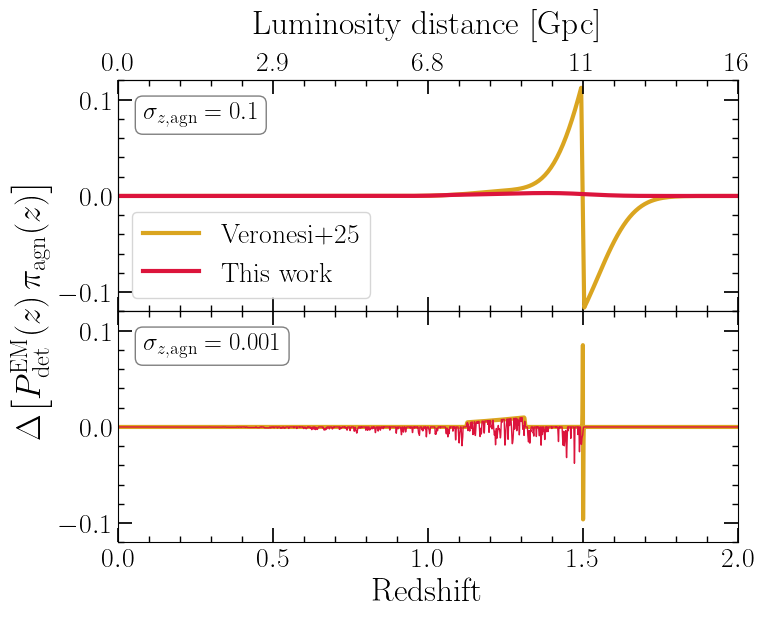

In [4]:
V25_0p001 = np.load(f'{PDET_DIR}/V25_0.001.npy')
P26_0p001 = np.load(f'{PDET_DIR}/P26_0.001.npy')
V25_0p1 = np.load(f'{PDET_DIR}/V25_0.1.npy')
P26_0p1 = np.load(f'{PDET_DIR}/P26_0.1.npy')
z_0p001 = np.linspace(0, 10, len(V25_0p001))
z_0p1 = np.linspace(0, 10, len(V25_0p1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6), gridspec_kw={'hspace': 0})
ax1.plot(z_0p1, V25_0p1, color='goldenrod', linewidth=3, label=r'Veronesi+25')
ax1.plot(z_0p1, P26_0p1, color='crimson', linewidth=3, label=r'This work')
ax2.plot(z_0p001, V25_0p001, color='goldenrod', linewidth=3, label=r'V25, $\sigma_{z, \rm agn} = 0.001$')
ax2.plot(z_0p001, P26_0p001, color='crimson', linewidth=1, label=r'P26, $\sigma_{z, \rm agn} = 0.001$')
ax1.text(
	0.04, 0.90,
	r'$\sigma_{z,\rm agn}=0.1$',
	transform=ax1.transAxes,
	ha='left',
	va='top',
	fontsize=18,
	bbox=dict(
		facecolor='white',
		edgecolor=(0, 0, 0, 0.5),
		boxstyle='round,pad=0.3')
)
ax2.text(
	0.04, 0.90,
	r'$\sigma_{z,\rm agn}=0.001$',
	transform=ax2.transAxes,
	ha='left',
	va='top',
	fontsize=18,
	bbox=dict(
		facecolor='white',
		edgecolor=(0, 0, 0, 0.5),
		boxstyle='round,pad=0.3')
)
upperax = ax1.twiny()
upperticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(upperticks)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)
upperax.set_xlim(0, 2)
ax1.set_ylim(-0.12, 0.12)
ax2.set_ylim(-0.12, 0.12)
ax1.set_xlim(0, 2)
ax2.set_xlim(0, 2)
ax1.set_xticklabels([])
ax2.set_xlabel('Redshift')
fig.supylabel(r'$\Delta\!\left[P^{\rm EM}_{\rm det}(z)\,\pi_{\rm agn}(z)\right]$', fontsize=25,  x=-0.01)
ax1.legend()
plt.savefig(f'{PLOT_DIR}/selfunc_error.pdf', bbox_inches='tight')

plt.show()


# Completeness vs sigma-z-AGN, colorbar sigma-fagn


### The unbiased case

In [5]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)
param_values_dict = {"AGN_ZERROR": agn_zerrs, "AGN_ZCUT": agn_zcuts}
sig_fagn, _ = sig_fagn_from_latest_runs(f"{JSON_DIR}/metadata_lowres_50grid_46p5_1p0.json", subdir='lowres_unbiased', param_values_dict=param_values_dict)
# sig_fagn, _ = sig_fagn_from_latest_runs(f"{JSON_DIR}/metadata_highres_200grid_46p5_1p0.json", subdir='highres_unbiased', param_values_dict=param_values_dict)
X, Y = np.meshgrid(agn_zcuts, agn_zerrs)


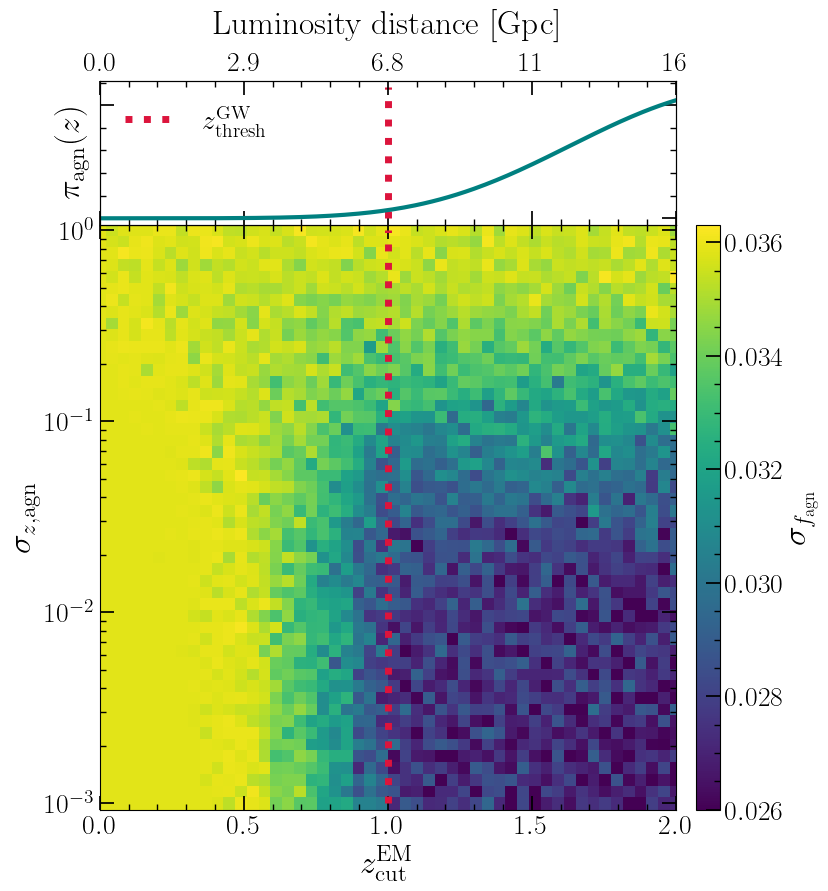

In [6]:
zthresh_color = 'crimson'
fig = plt.figure(figsize=(8,9))

# ---- GEOMETRY ----
left = 0.12
bottom = 0.10
main_height = 0.65
main_width  = 0.72
top_height = 0.16
ax = fig.add_axes([left, bottom, main_width, main_height])
ax_top = fig.add_axes([left, bottom + main_height, main_width, top_height], sharex=ax)
cax = fig.add_axes([left + main_width + 0.025, bottom, 0.03, main_height])

# ---- MAIN PLOT ----
pcm = ax.pcolormesh(
	X, Y, scale_sig(sig_fagn),
	shading='auto',
	cmap='viridis',
	rasterized=True,
	vmin=0.026
	# vmin=0.026, vmax=0.036
)
ax.vlines(1, 1e-3, 1, linestyle='dotted', color=zthresh_color, linewidth=5)
ax.set_xlabel(r"$z_{\rm cut}^{\rm EM}$")
ax.set_ylabel(r"$\sigma_{z,\rm agn}$")
ax.set_yscale('log')

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"$\sigma_{f_{\rm agn}}$")

# ---- TOP PANEL ----
z, agnpdf = np.load(f'{AGN_DIST_DIR}/agn_redshift_pdf_46.5_kulkarni.npy')
ax_top.plot(z, agnpdf, color='teal', linewidth=3, zorder=5)
ax_top.vlines(1, 0, np.max(agnpdf), linestyle='dotted', color=zthresh_color, linewidth=5, label=r'$z_{\rm thresh}^{\rm GW}$')
ax_top.legend(framealpha=0)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.set_ylabel(r'$\pi_{\rm agn}(z)$')
ax_top.set_yticklabels([])
ax_top.set_xlim(X.min(), X.max())

# Top axis
upperax = ax_top.twiny()
upperticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(upperticks)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)
upperax.set_xlim(X.min(), X.max())

plt.savefig(f'{PLOT_DIR}/cat_quality_mock.pdf', bbox_inches='tight')

plt.show()


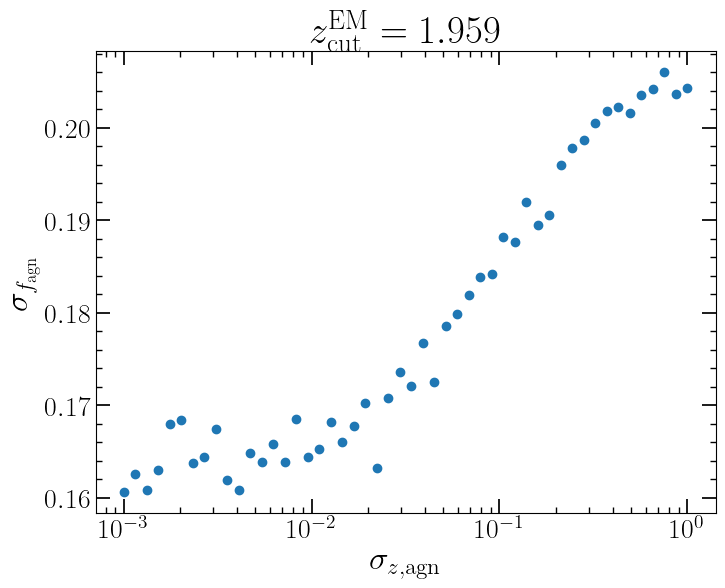

In [7]:
# At fixed z_cut^EM, we see the error on f_agn keeps decreasing with sigma_z,agn. However, there are diminishing returns.

agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = [np.linspace(0, 2, 50)[-2]]
param_values_dict = {"AGN_ZERROR": agn_zerrs, "AGN_ZCUT": agn_zcuts}
s, _ = sig_fagn_from_latest_runs(f"{JSON_DIR}/metadata_highres_200grid_46p5_1p0.json", subdir='highres_unbiased', param_values_dict=param_values_dict)

plt.figure(figsize=(8,6))
plt.scatter(agn_zerrs, s)
plt.semilogx()
plt.xlabel(r'$\sigma_{z, \rm agn}$')
plt.ylabel(r'$\sigma_{f_{\rm agn}}$')
plt.title(rf'$z_{{\rm cut}}^{{\rm EM}} = {agn_zcuts[0]:.3f}$')
plt.show()


### The biased case: neglecting redshift errors

In [11]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)
param_values_dict = {"AGN_ZERROR": agn_zerrs, "AGN_ZCUT": agn_zcuts}
sig_fagn_biased, mean_deviation = sig_fagn_from_latest_runs(f"{JSON_DIR}/metadata_highres_200grid_46p5_1p0_biased.json", subdir='highres_biased', param_values_dict=param_values_dict)
X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

zcut_quaia = 1.5
i = np.searchsorted(agn_zerrs, median_err_quaia)
j = np.searchsorted(agn_zcuts, zcut_quaia)
print(f'Median quaia bias: {mean_deviation[i, j]:.2f} sigma')


Median quaia bias: -0.46 sigma


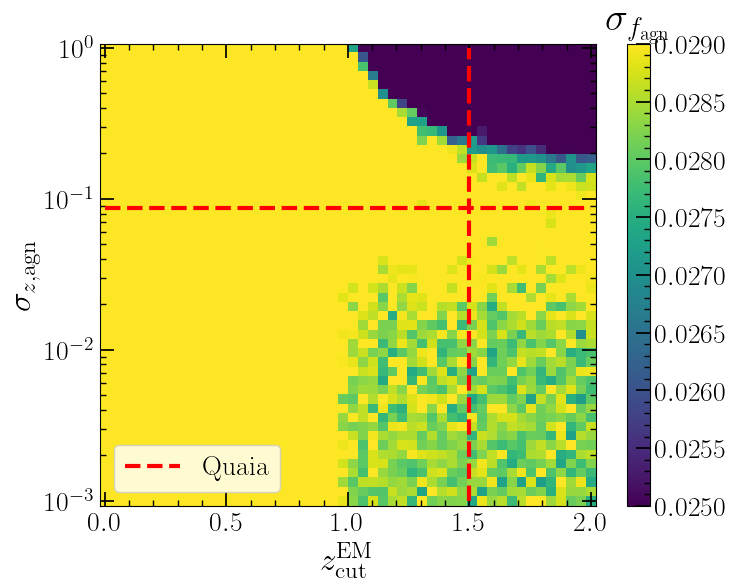

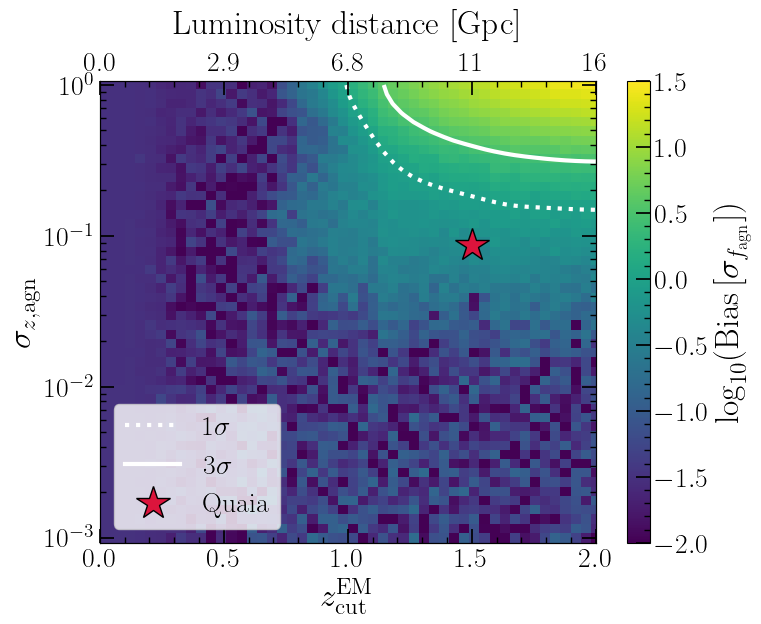

In [12]:
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, scale_sig(sig_fagn_biased), shading='auto', cmap='viridis', rasterized=True, vmin=0.025, vmax=0.029)
plt.hlines(median_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(zcut_quaia, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}^{\rm EM}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm)
cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig(f'{PLOT_DIR}/constraint_catalog_quality_biased.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
conts = [np.log10(1), np.log10(3)]
m = np.log10(abs(mean_deviation))
m_smooth = gaussian_filter(m, sigma=2.0)
pcm = plt.pcolormesh(X, Y, m, shading='auto', cmap='viridis', rasterized=True, vmin=-2, vmax=1.5)
cs = plt.contour(X, Y, m_smooth, levels=conts, colors='white', linewidths=3, linestyles=['dotted', 'solid'])
plt.plot(1.5, median_err_quaia, color=COLORS[6], linewidth=3, linestyle=' ', marker='*', markeredgecolor='black', markersize=25, label='Quaia')
plt.xlabel(r"$z^{\rm EM}_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\log_{10}(\mathrm{Bias} \, [\sigma_{f_{\rm agn}}])$")
plt.yscale('log')

# Top axis
upperax = ax.twiny()
upperticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(upperticks)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)
ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())

plt.legend(loc='lower left', 
		   handles=[mlines.Line2D([], [], color='white', linewidth=3, label=r"$1\sigma$", linestyle='dotted'),
					mlines.Line2D([], [], color='white', linewidth=3, label=r"$3\sigma$"),
					mlines.Line2D([], [], color=COLORS[6], linewidth=3, linestyle=' ', marker='*', markeredgecolor='black', markersize=25, label='Quaia')])
plt.savefig(f'{PLOT_DIR}/bias_agn_zerror.pdf', bbox_inches='tight')
plt.show()


# Limiting cases: perfect catalogue and empty catalogue

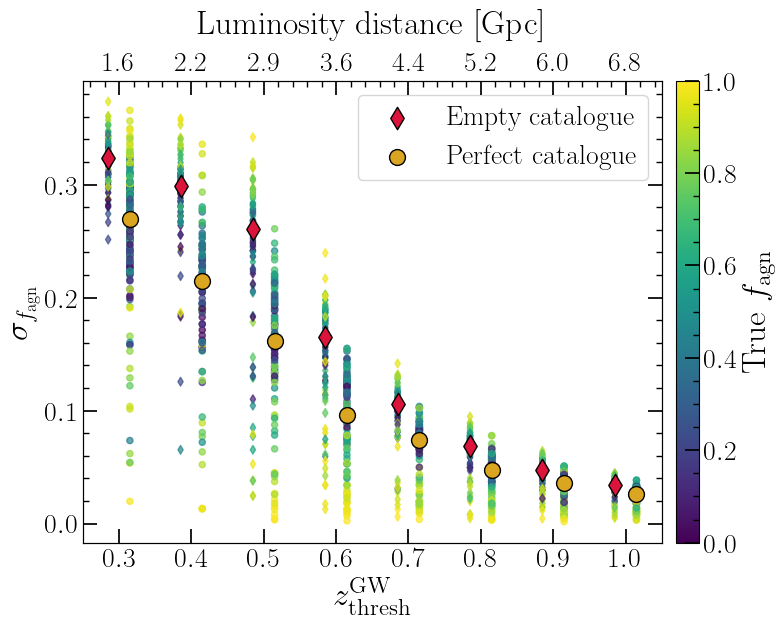

In [13]:
# z_thresh^GW: (N_inj, empty-catalogue posteriors, perfect-catalogue posteriors)
cases = {
	.3: (1e5, "2026-06-01T14:00:05.335445", "2026-06-03T13:23:17.190061"),
	.4: (1e5, "2026-06-02T14:24:08.136028", "2026-06-03T12:55:24.817817"),
	.5: (1e5, "2026-06-02T12:35:35.144718", "2026-06-03T12:38:28.160445"),
	.6: (5e4, "2026-06-01T17:31:26.596947", "2026-06-01T17:49:39.424950"),
	.7: (2e4, "2026-06-01T13:56:50.071755", "2026-06-01T14:13:07.208748"),
	.8: (1e4, "2026-06-01T18:04:11.351191", "2026-06-01T18:10:16.617420"),
	.9: (5e3, "2026-06-01T17:55:47.568877", "2026-06-01T17:59:15.731813"),
	1.0: (3e3, "2026-06-01T14:01:32.995834", "2026-06-01T14:22:05.703371"),
}

fig, ax = plt.subplots(figsize=(9, 6))
dx = .015

perfect_cat = []
empty_cat = []
for z, (N, *timestamps) in cases.items():
	for i, timestamp in enumerate(timestamps):
		fname = f"p26_post_realdata_False_{timestamp}.npz"
		posterior, _, true_fagns = load_log_llh(filename=fname, subdir='limiting_cases', fagn_true=None)
		true_fagns = true_fagns[:200]  # Use all of them
		posterior, _ = filter_posteriors(posterior, 0, 200)

		_, q005, q016, q050, q084, q095 = eval_cdfs(posterior, true_fagns)
		sig = scale_sig((q084 - q016) / 2, N_have=N)

		marker, color = ("d", "crimson") if i == 0 else ("o", "goldenrod")
		zplot = z + (-dx if i == 0 else dx)

		plt.scatter(np.full_like(sig, zplot), sig, c=true_fagns, alpha=0.7, s=20, vmin=0, vmax=1, marker=marker)
		plt.scatter(zplot, np.median(sig), color=color, zorder=10, marker=marker, s=130, edgecolor='black')

		if i == 0:
			empty_cat.append(np.median(sig))
		elif i == 1:
			perfect_cat.append(np.median(sig))
empty_cat = np.array(empty_cat)
perfect_cat = np.array(perfect_cat)

plt.colorbar(label=r'True $f_{\rm agn}$', pad=0.02)

for marker, color, label in [("d", "crimson", "Empty catalogue"),
							 ("o", "goldenrod", "Perfect catalogue")]:
	ax.scatter([], [], color=color, marker=marker, s=130,
			   edgecolor="black", label=label)

ax.legend()
ax.set(xlabel=r"$z_{\rm thresh}^{\rm GW}$",
	   ylabel=r"$\sigma_{f_{\rm agn}}$",
	   xticks=np.arange(.3, 1.01, .1), xlim=(.25, 1.05))
ax.xaxis.set_minor_locator(plt.NullLocator())

upperax = ax.twiny()
upperax.set(xlim=ax.get_xlim(), xticks=np.arange(.3, 1.01, .1),
			xticklabels=[sigfig_str(v, 2) for v in
						 COSMO.luminosity_distance(np.arange(.3, 1.01, .1)).to_value(u.Gpc)],
			xlabel=r"Luminosity distance $[\mathrm{Gpc}]$")
upperax.xaxis.labelpad = 12

plt.savefig(f"{PLOT_DIR}/limits_mock.pdf", bbox_inches="tight")
plt.show()


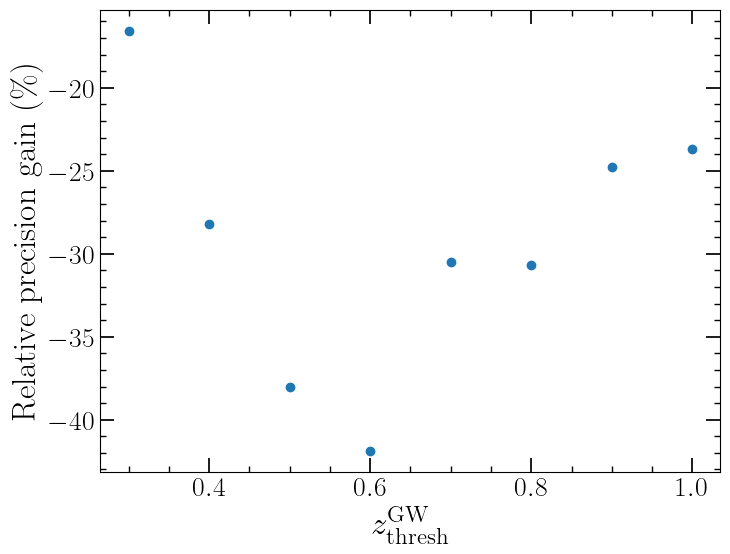

[-16.55204857 -28.19917114 -38.02904633 -41.86535155 -30.51956824
 -30.70013996 -24.77583804 -23.66890076] -29.288758072624496 7.528532781465781


In [14]:
x = cases.keys()
plt.figure(figsize=(8,6))
plt.scatter(x, (perfect_cat - empty_cat) / empty_cat * 100)
plt.xlabel(r"$z_{\rm thresh}^{\rm GW}$")
plt.ylabel(r'Relative precision gain (\%)')
plt.show()

print((perfect_cat - empty_cat) / empty_cat * 100, np.mean((perfect_cat - empty_cat) / empty_cat * 100), np.std((perfect_cat - empty_cat) / empty_cat * 100))


# PP-plot

Median 90% CI size = 0.8321090199825247
Median 1 sigma = 0.3084609539218781
Mean 1 sigma = 0.3052700918666576



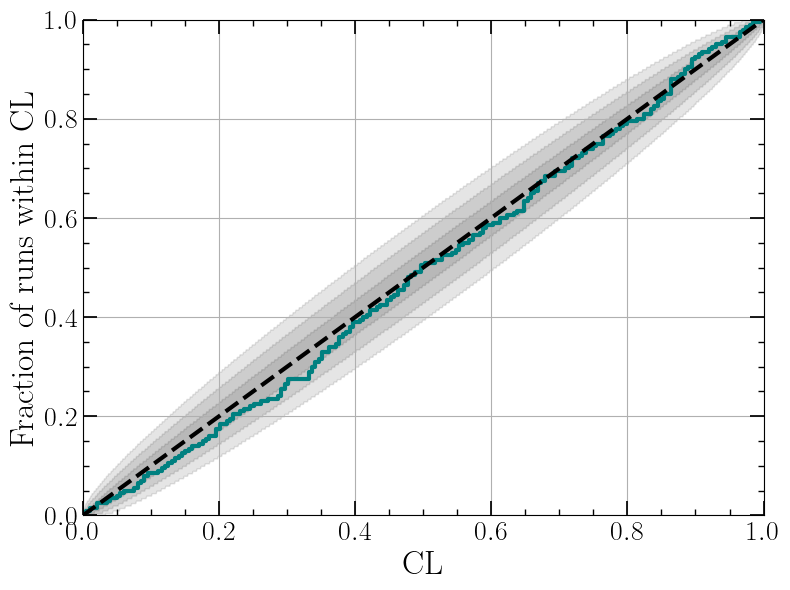

In [15]:
fnames = [f'p26_post_realdata_False_2026-06-03T11:48:52.256318.npz']  # EM: Quaia-like, GW: z_thresh^GW = 0.3

start = 0
stop = 200
fagn_true = None

fig1, ax2 = plt.subplots(figsize=(8,6))
for idx, fname in enumerate(fnames):

    posterior, posteriors_shape, true_fagns = load_log_llh(filename=fname, subdir='pp_plot', fagn_true=fagn_true)
    true_fagns = true_fagns[start:stop]
    posterior, posteriors_shape = filter_posteriors(posterior, start, stop)

    pdfs = get_pdfs(posterior, LOG_LLH_X_AX)

    cdf_at_true_val, q005, q016, q050, q084, q095 = eval_cdfs(posterior, true_fagns)
    print(f'Median 90% CI size = {np.median(q095[~np.isnan(q095)] - q005[~np.isnan(q095)])}')
    print(f'Median 1 sigma = {np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}')
    print(f'Mean 1 sigma = {np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}\n')

    sig = (q084 - q016)/2


    ########## Plotting ##########

    # PP plot
    Nrep = len(cdf_at_true_val)
    comparisons = np.linspace(0, 1, Nrep)
    pp_plot = np.zeros(Nrep)
    for i in range(len(pp_plot)):
        pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
    pp_plot /= len(cdf_at_true_val)

    ax2.step(comparisons, pp_plot, linewidth=3, color='teal')  # COLORS[idx], label=labels[k]

CI = np.linspace(0, 0.9999, 1000)
for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.1,0.1]):
    edge_of_bound = (1. - ci) / 2.
    lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
    upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
    lower[0] = 0
    upper[0] = 0
    plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid()
ax2.set_xlabel('CL')
ax2.set_ylabel('Fraction of runs within CL')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/ppplot_0p3.pdf', bbox_inches='tight')
plt.show()
